# Experiment 14: Spatial-SAINT v2

**Optimised for Google Colab T4 GPU**

| Change | Reason |
|--------|--------|
| Mixed precision fp16 | 2-3x faster per epoch on T4 |
| Focal Loss | Fixes TReg (0.68 F1) and M1 (0.81 F1) |
| d_model=128 (was 64) | More model capacity |
| n_layers=4 (was 3) | Deeper network |
| batch_size=256 (was 512) | Faster row attention O(N2) |
| max_epochs=400, patience=40 | More training time |

## 0. Setup

In [1]:
import os, random, math, time, copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler, SequentialSampler
from torch.cuda.amp import autocast, GradScaler   # mixed precision

SEED   = 7325111
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def set_seed(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed(SEED)
print(f"Device : {DEVICE}")
print(f"PyTorch: {torch.__version__}")

Device : cuda
PyTorch: 2.10.0+cu128


## 1. Data Loading

In [2]:
df = pd.read_csv("cHL_CODEX_annotation.csv")

MARKER_COLS = [
    'BCL.2','CCR6','CD11b','CD11c','CD15','CD16','CD162','CD163',
    'CD2','CD20','CD206','CD25','CD30','CD31','CD4','CD44',
    'CD45RA','CD45RO','CD45','CD5','CD56','CD57','CD68','CD69',
    'CD7','CD8','Collagen.4','Cytokeratin','DAPI.01','EGFR',
    'FoxP3','Granzyme.B','HLA.DR','IDO.1','LAG.3','MCT','MMP.9',
    'MUC.1','PD.1','PD.L1','Podoplanin','T.bet','TCR.g.d','TCRb',
    'Tim.3','VISA','Vimentin','a.SMA','b.Catenin',
]
FEATURE_COLS  = MARKER_COLS + ['cellSize']    # 50 features
SPATIAL_COLS  = ['X_cent', 'Y_cent']

CLASS_NAMES = ['B','CD4','CD8','DC','Endothelial','Epithelial',
               'Lymphatic','M1','M2','Mast','Monocyte','NK',
               'Neutrophil','Other','TReg','Tumor']
LABEL_MAP    = {n: i for i, n in enumerate(CLASS_NAMES)}
NUM_CLASSES  = len(CLASS_NAMES)   # 16
NUM_FEATURES = len(FEATURE_COLS)  # 50

df           = df[df['cellType'].isin(CLASS_NAMES)].reset_index(drop=True)
X_markers    = df[FEATURE_COLS].values.astype(np.float32)
X_spatial    = df[SPATIAL_COLS].values.astype(np.float32)
y_all        = df['cellType'].map(LABEL_MAP).values.astype(np.int64)

print(f"\nDataset : {len(df):,} cells | Features: {NUM_FEATURES} | Classes: {NUM_CLASSES}")
print(f"X range : [{X_spatial[:,0].min():.0f}, {X_spatial[:,0].max():.0f}]")
print(f"Y range : [{X_spatial[:,1].min():.0f}, {X_spatial[:,1].max():.0f}]")

print("\nClass distribution:")
for name, idx in sorted(LABEL_MAP.items(), key=lambda x: x[1]):
    count = (y_all == idx).sum()
    print(f"  {name:15s}: {count:6,} ({count/len(y_all)*100:5.1f}%)")


Dataset : 143,346 cells | Features: 50 | Classes: 16
X range : [3, 8083]
Y range : [2, 8006]

Class distribution:
  B              : 16,196 ( 11.3%)
  CD4            : 37,480 ( 26.1%)
  CD8            : 17,184 ( 12.0%)
  DC             :  9,637 (  6.7%)
  Endothelial    :  8,705 (  6.1%)
  Epithelial     :  2,251 (  1.6%)
  Lymphatic      :  3,768 (  2.6%)
  M1             :  3,101 (  2.2%)
  M2             :  7,286 (  5.1%)
  Mast           :  3,324 (  2.3%)
  Monocyte       :  6,913 (  4.8%)
  NK             :  7,339 (  5.1%)
  Neutrophil     :  3,442 (  2.4%)
  Other          :  5,108 (  3.6%)
  TReg           :  3,352 (  2.3%)
  Tumor          :  8,260 (  5.8%)


## 2. Train/Valid Split + Normalisation

In [3]:
(X_train_m, X_valid_m,
 X_train_s, X_valid_s,
 y_train,   y_valid) = train_test_split(
    X_markers, X_spatial, y_all,
    test_size=0.2, random_state=42, stratify=y_all
)

scaler_m  = StandardScaler()
X_train_m = scaler_m.fit_transform(X_train_m).astype(np.float32)
X_valid_m = scaler_m.transform(X_valid_m).astype(np.float32)

scaler_s  = StandardScaler()
X_train_s = scaler_s.fit_transform(X_train_s).astype(np.float32)
X_valid_s = scaler_s.transform(X_valid_s).astype(np.float32)

print(f"\nTrain: {len(y_train):,} | Valid: {len(y_valid):,}")


Train: 114,676 | Valid: 28,670


## 3. Dataset & DataLoaders

In [4]:
class CODEXDataset(Dataset):
    def __init__(self, X_m, X_s, y):
        self.X_m = torch.tensor(X_m, dtype=torch.float32)
        self.X_s = torch.tensor(X_s, dtype=torch.float32)
        self.y   = torch.tensor(y,   dtype=torch.long)

    def __len__(self):          return len(self.y)
    def __getitem__(self, i):   return self.X_m[i], self.X_s[i], self.y[i]


def make_loaders(X_m_tr, X_s_tr, y_tr,
                 X_m_va, X_s_va, y_va, batch_size=256):
    ds_tr   = CODEXDataset(X_m_tr, X_s_tr, y_tr)
    ds_va   = CODEXDataset(X_m_va, X_s_va, y_va)

    counts  = np.bincount(y_tr, minlength=NUM_CLASSES).astype(float)
    weights = (1.0 / np.where(counts == 0, 1, counts))[y_tr]
    sampler = WeightedRandomSampler(weights, len(weights), replacement=True)

    tr_loader = DataLoader(ds_tr, batch_size=batch_size, sampler=sampler,
                           drop_last=True,  num_workers=2, pin_memory=True)
    va_loader = DataLoader(ds_va, batch_size=batch_size,
                           sampler=SequentialSampler(ds_va),
                           drop_last=False, num_workers=2, pin_memory=True)
    return tr_loader, va_loader

## 4. Focal Loss  [NEW — fixes rare class (TReg, M1) problem]

In [5]:
class FocalLoss(nn.Module):
    """
    Focal Loss: down-weights easy examples, focuses on hard ones.
    gamma=2 is standard. label_smoothing prevents overconfidence.
    This directly addresses TReg (0.68 F1) and M1 (0.81 F1).
    """
    def __init__(self, gamma=2.0, label_smoothing=0.1, weight=None):
        super().__init__()
        self.gamma           = gamma
        self.label_smoothing = label_smoothing
        self.weight          = weight

    def forward(self, logits, targets):
        ce = F.cross_entropy(
            logits, targets,
            weight=self.weight,
            label_smoothing=self.label_smoothing,
            reduction='none'
        )
        pt           = torch.exp(-ce)
        focal_weight = (1 - pt) ** self.gamma
        return (focal_weight * ce).mean()

## 5. Spatial-SAINT Architecture  (same as v1, no changes here)

In [6]:
class FeatureTokenizer(nn.Module):
    def __init__(self, n_features, d_model):
        super().__init__()
        self.W = nn.Parameter(torch.empty(n_features, d_model))
        self.b = nn.Parameter(torch.zeros(n_features, d_model))
        nn.init.kaiming_uniform_(self.W, a=math.sqrt(5))

    def forward(self, x):
        return x.unsqueeze(-1) * self.W + self.b


class SpatialEncoding(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(2, d_model), nn.GELU(), nn.Linear(d_model, d_model),
        )

    def forward(self, xy):
        return self.proj(xy)


class ColAttention(nn.Module):
    """Self-attention ACROSS FEATURES within each cell."""
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        self.norm = nn.LayerNorm(d_model)
        self.attn = nn.MultiheadAttention(d_model, n_heads,
                                          dropout=dropout, batch_first=True)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        h = self.norm(x)
        h, _ = self.attn(h, h, h)
        return x + self.drop(h)


class RowAttention(nn.Module):
    """Inter-sample attention ACROSS CELLS in the batch."""
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        self.norm = nn.LayerNorm(d_model)
        self.attn = nn.MultiheadAttention(d_model, n_heads,
                                          dropout=dropout, batch_first=True)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        B, S, D = x.shape
        x_t     = x.permute(1, 0, 2)
        h       = self.norm(x_t)
        h, _    = self.attn(h, h, h)
        x_t     = x_t + self.drop(h)
        return x_t.permute(1, 0, 2)


class FFNBlock(nn.Module):
    def __init__(self, d_model, mult=4, dropout=0.1):
        super().__init__()
        self.norm = nn.LayerNorm(d_model)
        self.ffn  = nn.Sequential(
            nn.Linear(d_model, d_model * mult), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * mult, d_model), nn.Dropout(dropout),
        )

    def forward(self, x):
        return x + self.ffn(self.norm(x))


class SAINTBlock(nn.Module):
    def __init__(self, d_model, n_heads, ffn_mult=4, dropout=0.1):
        super().__init__()
        self.col = ColAttention(d_model, n_heads, dropout)
        self.row = RowAttention(d_model, n_heads, dropout)
        self.ffn = FFNBlock(d_model, ffn_mult, dropout)

    def forward(self, x):
        x = self.col(x)
        x = self.row(x)
        x = self.ffn(x)
        return x


class SpatialSAINT(nn.Module):
    def __init__(self, num_features=50, d_model=128, n_heads=8,
                 n_layers=4, ffn_mult=4, dropout=0.1, num_classes=16):
        super().__init__()
        self.tokenizer   = FeatureTokenizer(num_features, d_model)
        self.spatial_enc = SpatialEncoding(d_model)
        self.cls_token   = nn.Parameter(torch.zeros(1, 1, d_model))

        self.blocks = nn.ModuleList([
            SAINTBlock(d_model, n_heads, ffn_mult, dropout)
            for _ in range(n_layers)
        ])

        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, num_classes),
        )

    def forward(self, x_markers, x_spatial):
        B      = x_markers.size(0)
        tokens = self.tokenizer(x_markers)
        sp     = self.spatial_enc(x_spatial).unsqueeze(1)
        tokens = tokens + sp
        cls    = self.cls_token.expand(B, -1, -1)
        tokens = torch.cat([cls, tokens], dim=1)
        for block in self.blocks:
            tokens = block(tokens)
        return self.head(tokens[:, 0])

## 6. Training Function  [mixed precision added]

In [7]:
def train_spatial_saint_v2(
    X_m_tr, X_s_tr, y_tr,
    X_m_va, X_s_va, y_va,
    d_model=128, n_heads=8, n_layers=4, ffn_mult=4,
    dropout=0.1, batch_size=256,
    max_epochs=400, patience=40, lr=3e-4,
):
    set_seed(SEED)
    tr_loader, va_loader = make_loaders(
        X_m_tr, X_s_tr, y_tr,
        X_m_va, X_s_va, y_va, batch_size=batch_size
    )

    model = SpatialSAINT(
        num_features=NUM_FEATURES,
        d_model=d_model, n_heads=n_heads,
        n_layers=n_layers, ffn_mult=ffn_mult,
        dropout=dropout, num_classes=NUM_CLASSES,
    ).to(DEVICE)

    n_params = sum(p.numel() for p in model.parameters())
    print(f"\nSpatial-SAINT v2 | Params: {n_params:,}")
    print(f"  d_model={d_model}, heads={n_heads}, layers={n_layers}, batch={batch_size}")
    print(f"  Mixed precision: {DEVICE.type == 'cuda'}")

    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=max_epochs, eta_min=1e-5
    )
    criterion = FocalLoss(gamma=2.0, label_smoothing=0.1)

    # Mixed precision scaler (only active on CUDA)
    scaler  = GradScaler(enabled=(DEVICE.type == 'cuda'))

    best_f1, best_state, pat_ctr = 0.0, None, 0
    history = []

    for epoch in range(max_epochs):
        # ── Train ──
        model.train()
        t0 = time.time()
        for X_m, X_s, y_b in tr_loader:
            X_m, X_s, y_b = X_m.to(DEVICE), X_s.to(DEVICE), y_b.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)

            with autocast(enabled=(DEVICE.type == 'cuda')):
                logits = model(X_m, X_s)
                loss   = criterion(logits, y_b)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()

        scheduler.step()

        # ── Validate ──
        model.eval()
        all_preds = []
        with torch.no_grad():
            for X_m, X_s, _ in va_loader:
                with autocast(enabled=(DEVICE.type == 'cuda')):
                    logits = model(X_m.to(DEVICE), X_s.to(DEVICE))
                all_preds.append(logits.argmax(1).cpu().numpy())

        preds  = np.concatenate(all_preds)
        val_f1 = f1_score(y_va, preds, average='weighted')
        history.append(val_f1)

        if val_f1 > best_f1:
            best_f1    = val_f1
            best_state = copy.deepcopy(model.state_dict())
            pat_ctr    = 0
            print(f"  Epoch {epoch:3d} | W-F1: {val_f1:.4f} BEST | {time.time()-t0:.1f}s")
        else:
            pat_ctr += 1

        if pat_ctr >= patience and epoch >= 80:
            print(f"  Early stop at epoch {epoch}")
            break

    model.load_state_dict(best_state)
    print(f"\nBest Validation W-F1: {best_f1:.4f}")
    return model, best_f1, history

## 7. Run Experiment

In [8]:
print("\n" + "="*60)
print("TRAINING SPATIAL-SAINT v2")
print("="*60)

model, best_f1, history = train_spatial_saint_v2(
    X_train_m, X_train_s, y_train,
    X_valid_m, X_valid_s, y_valid,
    d_model    = 128,
    n_heads    = 8,
    n_layers   = 4,
    batch_size = 256,
    max_epochs = 400,
    patience   = 40,
    lr         = 3e-4,
)


TRAINING SPATIAL-SAINT v2

Spatial-SAINT v2 | Params: 1,090,448
  d_model=128, heads=8, layers=4, batch=256
  Mixed precision: True


/tmp/ipykernel_7950/319616251.py:33: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler  = GradScaler(enabled=(DEVICE.type == 'cuda'))
/tmp/ipykernel_7950/319616251.py:46: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE.type == 'cuda')):
/tmp/ipykernel_7950/319616251.py:63: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE.type == 'cuda')):


  Epoch   0 | W-F1: 0.7779 BEST | 39.0s


/tmp/ipykernel_7950/319616251.py:46: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE.type == 'cuda')):
/tmp/ipykernel_7950/319616251.py:63: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE.type == 'cuda')):


  Epoch   1 | W-F1: 0.7991 BEST | 38.6s


...

  Epoch 114 | W-F1: 0.8774 BEST | 39.8s


/tmp/ipykernel_7950/319616251.py:46: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE.type == 'cuda')):
/tmp/ipykernel_7950/319616251.py:63: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE.type == 'cuda')):
/tmp/ipykernel_7950/319616251.py:46: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE.type == 'cuda')):
/tmp/ipykernel_7950/319616251.py:63: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE.type == 'cuda')):
/tmp/ipykernel_7950/319616251.py:46: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


  Epoch 149 | W-F1: 0.8787 BEST | 39.8s


/tmp/ipykernel_7950/319616251.py:46: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE.type == 'cuda')):
/tmp/ipykernel_7950/319616251.py:63: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE.type == 'cuda')):
/tmp/ipykernel_7950/319616251.py:46: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE.type == 'cuda')):
/tmp/ipykernel_7950/319616251.py:63: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE.type == 'cuda')):
/tmp/ipykernel_7950/319616251.py:46: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


  Early stop at epoch 189

Best Validation W-F1: 0.8787


## 8. Full Evaluation

In [9]:
model.eval()
all_preds, all_probs = [], []

ds_va     = CODEXDataset(X_valid_m, X_valid_s, y_valid)
va_loader = DataLoader(ds_va, batch_size=256,
                       sampler=SequentialSampler(ds_va), num_workers=2)

with torch.no_grad():
    for X_m, X_s, _ in va_loader:
        with autocast(enabled=(DEVICE.type == 'cuda')):
            logits = model(X_m.to(DEVICE), X_s.to(DEVICE))
        probs  = F.softmax(logits.float(), dim=-1).cpu().numpy()
        all_probs.append(probs)
        all_preds.append(probs.argmax(1))

final_preds = np.concatenate(all_preds)
final_probs = np.concatenate(all_probs)

wf1 = f1_score(y_valid, final_preds, average='weighted')
mf1 = f1_score(y_valid, final_preds, average='macro')

print("\n" + "="*60)
print("SPATIAL-SAINT v2 FINAL RESULTS")
print("="*60)
print(f"  Weighted F1 : {wf1:.4f}")
print(f"  Macro F1    : {mf1:.4f}")
print("\nPer-class report:")
print(classification_report(y_valid, final_preds, target_names=CLASS_NAMES))

print("\n" + "="*60)
print("COMPARISON vs BASELINES")
print("="*60)
print(f"  MAPS (published)            : ~90.00%")
print(f"  Ensemble Exp-12 (3 models)  :  90.37%")
print(f"  FT-Transformer (FYDP-III)   :  87.00%")
print(f"  Spatial-SAINT v1 (1 model)  :  86.98%")
print(f"  Spatial-SAINT v2 (1 model)  :  {wf1*100:.2f}%  <- OURS")

/tmp/ipykernel_7950/2546895676.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE.type == 'cuda')):



SPATIAL-SAINT v2 FINAL RESULTS
  Weighted F1 : 0.8787
  Macro F1    : 0.8686

Per-class report:
              precision    recall  f1-score   support

           B       0.87      0.89      0.88      3239
         CD4       0.91      0.86      0.89      7496
         CD8       0.93      0.89      0.91      3437
          DC       0.81      0.84      0.82      1928
 Endothelial       0.91      0.93      0.92      1741
  Epithelial       0.87      0.88      0.88       450
   Lymphatic       0.90      0.92      0.91       754
          M1       0.78      0.84      0.81       620
          M2       0.86      0.86      0.86      1457
        Mast       0.93      0.96      0.95       665
    Monocyte       0.81      0.83      0.82      1383
          NK       0.87      0.88      0.88      1468
  Neutrophil       0.83      0.91      0.87       688
       Other       0.82      0.87      0.85      1022
        TReg       0.70      0.76      0.73       670
       Tumor       0.91      0.94     

## 9. Visualisations

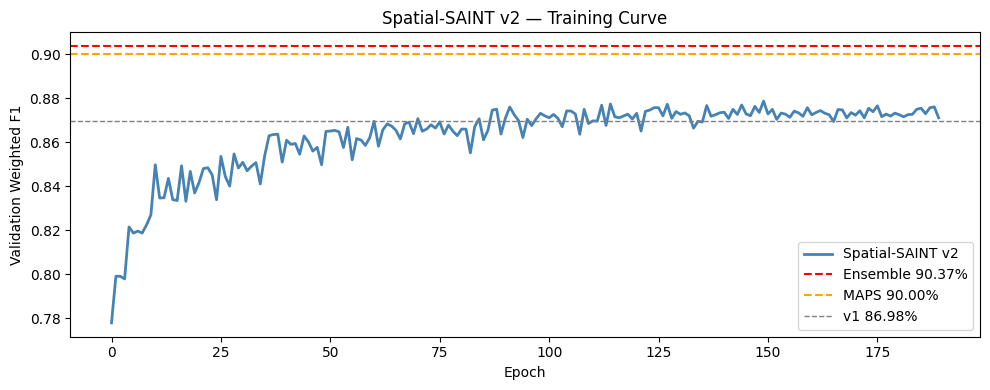

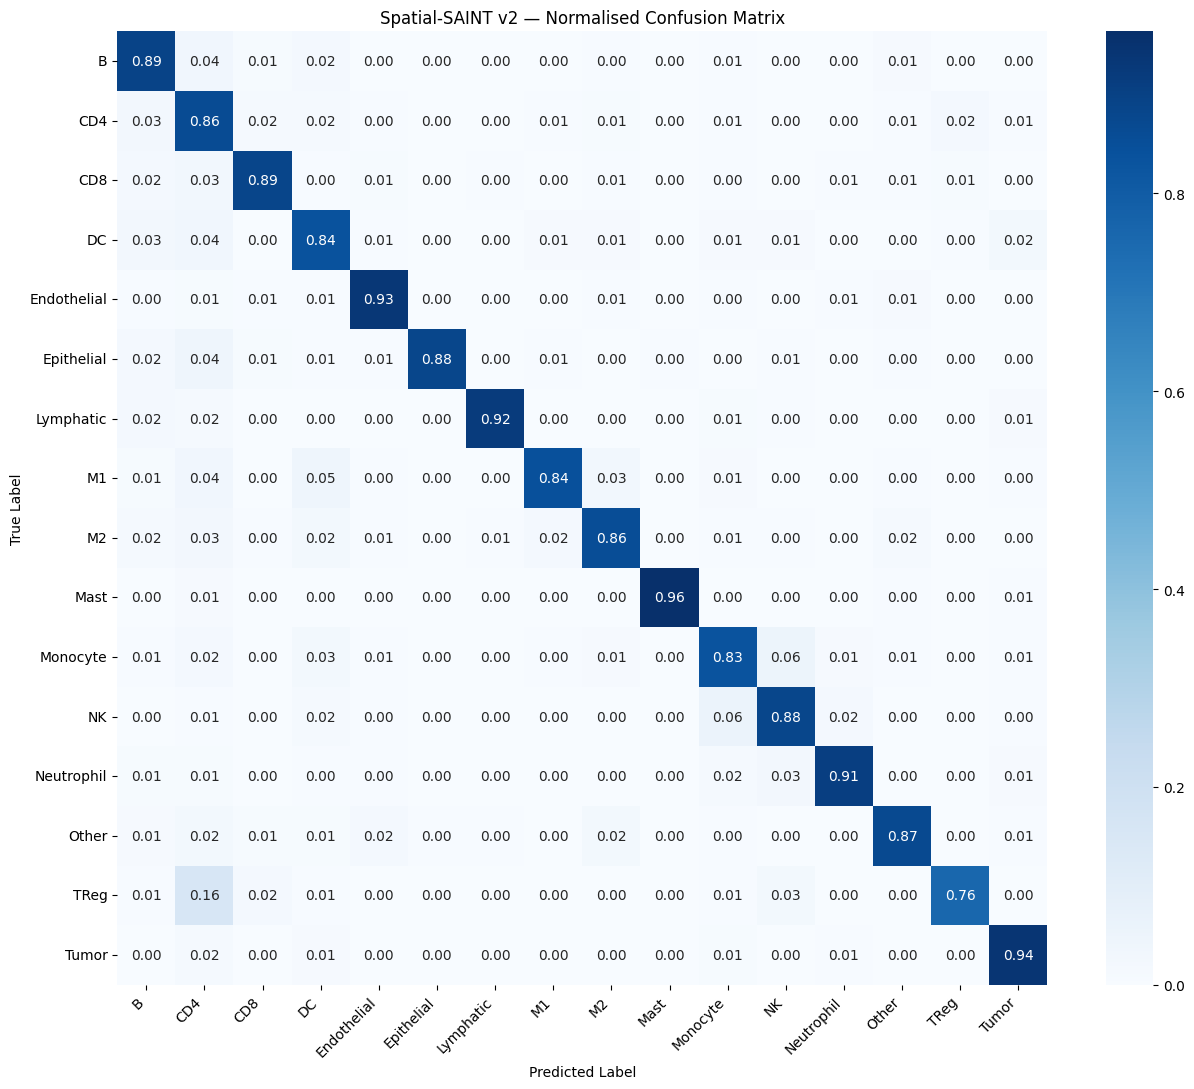

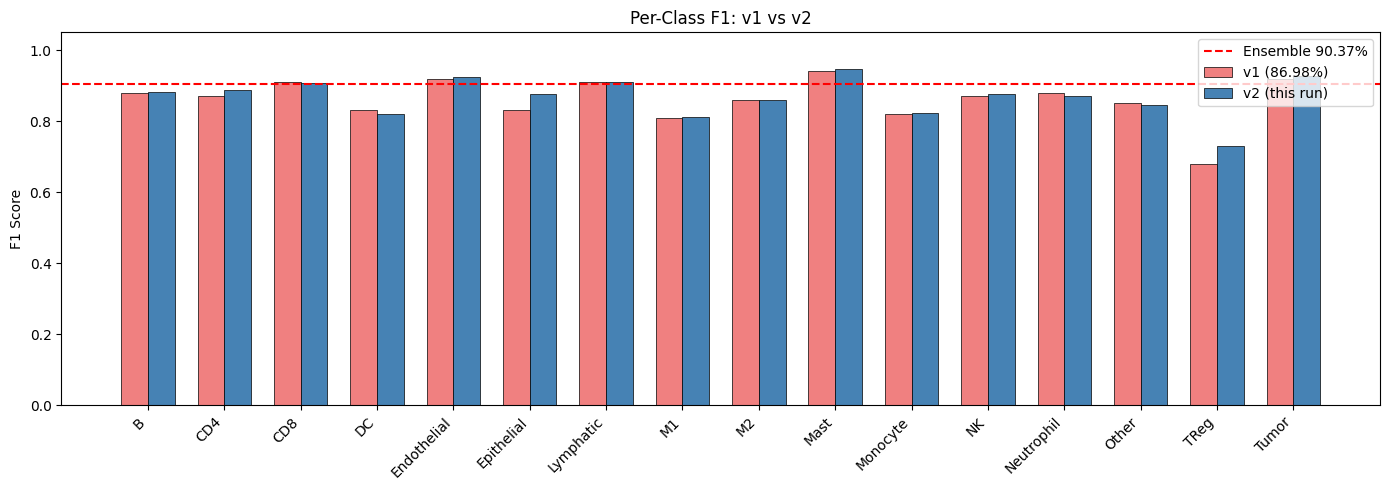


Done! Check PNG files for figures.
Final Weighted F1: 0.8787


In [10]:
# 9a. Training curve
plt.figure(figsize=(10, 4))
plt.plot(history, color='steelblue', linewidth=2, label='Spatial-SAINT v2')
plt.axhline(0.9037, color='red',    linestyle='--', linewidth=1.5, label='Ensemble 90.37%')
plt.axhline(0.9000, color='orange', linestyle='--', linewidth=1.5, label='MAPS 90.00%')
plt.axhline(0.8698, color='gray',   linestyle='--', linewidth=1.0, label='v1 86.98%')
plt.xlabel('Epoch')
plt.ylabel('Validation Weighted F1')
plt.title('Spatial-SAINT v2 — Training Curve')
plt.legend()
plt.tight_layout()
plt.savefig('saint_v2_training_curve.png', dpi=150)
plt.show()

# 9b. Confusion matrix
cm      = confusion_matrix(y_valid, final_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(13, 11))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Spatial-SAINT v2 — Normalised Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('saint_v2_confusion_matrix.png', dpi=150)
plt.show()

# 9c. Per-class F1 comparison (v1 vs v2)
per_class_f1_v2 = f1_score(y_valid, final_preds, average=None)
per_class_f1_v1 = [0.88,0.87,0.91,0.83,0.92,0.83,0.91,0.81,0.86,0.94,0.82,0.87,0.88,0.85,0.68,0.92]

x = np.arange(len(CLASS_NAMES))
w = 0.35
plt.figure(figsize=(14, 5))
plt.bar(x - w/2, per_class_f1_v1, w, label='v1 (86.98%)', color='lightcoral', edgecolor='black', lw=0.5)
plt.bar(x + w/2, per_class_f1_v2, w, label='v2 (this run)', color='steelblue', edgecolor='black', lw=0.5)
plt.axhline(0.9037, color='red', linestyle='--', linewidth=1.5, label='Ensemble 90.37%')
plt.xticks(x, CLASS_NAMES, rotation=45, ha='right')
plt.ylabel('F1 Score')
plt.title('Per-Class F1: v1 vs v2')
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.savefig('saint_v2_per_class_comparison.png', dpi=150)
plt.show()

print("\nDone! Check PNG files for figures.")
print(f"Final Weighted F1: {wf1:.4f}")